In [1]:
import datasets
from langchain_core.documents import Document
from langchain_community.retrievers import BM25Retriever
from langchain_community.tools import Tool 

from langgraph.graph import StateGraph , END , START , MessagesState 
from langgraph.prebuilt import ToolNode , tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()


f:\AI ML\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:

dataset = datasets.load_dataset("agents-course/unit3-invitees", split="train")

In [4]:
docs = [
    Document(
              page_content="\n".join([
            f"Name: {guest['name']}",
            f"Relation: {guest['relation']}",
            f"Description: {guest['description']}",
            f"Email: {guest['email']}"
        ]),
        metadata={"name": guest["name"]}
    )
    for guest in dataset
]

In [5]:
docs

[Document(metadata={'name': 'Ada Lovelace'}, page_content="Name: Ada Lovelace\nRelation: best friend\nDescription: Lady Ada Lovelace is my best friend. She is an esteemed mathematician and friend. She is renowned for her pioneering work in mathematics and computing, often celebrated as the first computer programmer due to her work on Charles Babbage's Analytical Engine.\nEmail: ada.lovelace@example.com"),
 Document(metadata={'name': 'Dr. Nikola Tesla'}, page_content="Name: Dr. Nikola Tesla\nRelation: old friend from university days\nDescription: Dr. Nikola Tesla is an old friend from your university days. He's recently patented a new wireless energy transmission system and would be delighted to discuss it with you. Just remember he's passionate about pigeons, so that might make for good small talk.\nEmail: nikola.tesla@gmail.com"),
 Document(metadata={'name': 'Marie Curie'}, page_content='Name: Marie Curie\nRelation: no relation\nDescription: Marie Curie was a groundbreaking physicist 

Document retiriver 

In [31]:
bm_retirver = BM25Retriever.from_documents(docs)


def extract_details(query : str) -> str:
    """Retrieves detailed information about gala guests based on their name or relation."""
    result = bm_retirver.invoke(query)
    print(result)
    if result:
        return result[0].page_content
    else: 
        "No details in the documents"

In [32]:
rag_extraction_tool = Tool(
    "rag_extraction_tool" , 
    extract_details ,
    "Retrieves detailed information about gala guests based on their name or relation."
)

In [33]:
llm = ChatGoogleGenerativeAI(
     model="gemini-3.1-flash-lite"
)

Bind llm with tools 

In [34]:
tools = [rag_extraction_tool]
llm_bind_tools = llm.bind_tools(tools)

In [35]:
#Simple assiantace 
def assitance(state: MessagesState):
    return {'messages': [llm_bind_tools.invoke(state['messages'])]
    }

Build a agent 

In [49]:
builder = StateGraph(MessagesState)
builder.add_node("assistance" , assitance)
builder.add_node('tools' , ToolNode(tools))

builder.add_edge(START , 'assistance')
builder.add_conditional_edges('assistance' , 
                             tools_condition)
builder.add_edge('tools' , 'assistance')

In [50]:
agent = builder.compile()

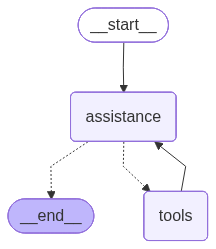

In [51]:
agent

In [54]:
result =  agent.invoke({
    "messages" : "Tell me about our guest named 'Lady Ada Lovelace'."
})

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


[Document(metadata={'name': 'Ada Lovelace'}, page_content="Name: Ada Lovelace\nRelation: best friend\nDescription: Lady Ada Lovelace is my best friend. She is an esteemed mathematician and friend. She is renowned for her pioneering work in mathematics and computing, often celebrated as the first computer programmer due to her work on Charles Babbage's Analytical Engine.\nEmail: ada.lovelace@example.com"), Document(metadata={'name': 'Marie Curie'}, page_content='Name: Marie Curie\nRelation: no relation\nDescription: Marie Curie was a groundbreaking physicist and chemist, famous for her research on radioactivity.\nEmail: marie.curie@example.com'), Document(metadata={'name': 'Dr. Nikola Tesla'}, page_content="Name: Dr. Nikola Tesla\nRelation: old friend from university days\nDescription: Dr. Nikola Tesla is an old friend from your university days. He's recently patented a new wireless energy transmission system and would be delighted to discuss it with you. Just remember he's passionate a

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [55]:
print(result['messages'][-1].content)

[{'type': 'text', 'text': "Lady Ada Lovelace is your best friend and an esteemed mathematician. She is widely celebrated for her pioneering work in computing and is often considered the first computer programmer due to her groundbreaking contributions to Charles Babbage's Analytical Engine. \n\nIf you need to reach her, her email address is ada.lovelace@example.com.", 'extras': {'signature': 'EjQKMgEMOdbHafOFTplKkY/qmkCg9k9gNfYZaoHXtnjhrBaCVfUsFLjHZqbxe+S9diKl2BZS'}}]
